# P7 baseline scoreboard

Reads Analysis/quantification/eval/scoreboard.csv and produces the report figures for the P7 baseline set: rule-based (TTP, SDM, Cy0) + F4 wMSE seeds 0-4.

In [1]:
import os
import pathlib
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Resolve project root: this notebook lives at <root>/notebooks/quantification/
NOTEBOOK_DIR = pathlib.Path(os.path.abspath(''))
# If running via nbconvert the CWD may already be the project root, or it may be
# the notebook directory — detect by checking for the expected CSV in both places.
CANDIDATE_ROOT = NOTEBOOK_DIR.parents[1]  # two levels up from notebooks/quantification
if (CANDIDATE_ROOT / "Analysis/quantification/eval/scoreboard.csv").exists():
    PROJECT_ROOT = CANDIDATE_ROOT
elif (NOTEBOOK_DIR / "Analysis/quantification/eval/scoreboard.csv").exists():
    PROJECT_ROOT = NOTEBOOK_DIR
else:
    raise FileNotFoundError(
        f"Cannot locate scoreboard.csv from CWD={NOTEBOOK_DIR}. "
        "Run this notebook from the project root."
    )

SCOREBOARD_CSV = PROJECT_ROOT / "Analysis/quantification/eval/scoreboard.csv"
FIGS_DIR = PROJECT_ROOT / "notebooks/quantification/figs"
FIGS_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(SCOREBOARD_CSV)
df.sort_values("min_cohens_d_adjacent", ascending=False, inplace=True)
df.reset_index(drop=True, inplace=True)
df

,method_id,config_json,min_cohens_d_adjacent,mean_cohens_d_adjacent,min_pairwise_auc_offdiag,mean_pairwise_auc_offdiag,delta_c_95,snr_conc,mean_analytical_sensitivity,pearson_r,r2,spearman_r,slope_min_per_decade,prediction_range_compression,pixel_mae_min,pixel_rmse_min,pixel_msd_min
0,f4_wmse_cnn1d_spatA3_seed1,"{""batch_size"": 32, ""cache"": ""regress_all_filt_...",-4.754482e-01,-1.454242e-01,0.506770,0.608872,14.674399,1.335635e-01,1.692084e-02,0.763802,0.583394,0.8,-0.807822,0.303131,7.706346,9.827383,6.662274
1,f4_wmse_cnn1d_spatA3_seed2,"{""batch_size"": 32, ""cache"": ""regress_all_filt_...",-5.365685e-01,-4.026840e-01,0.562084,0.718852,5.020616,3.903832e-01,1.676499e-01,0.983174,0.966632,1.0,-0.836237,0.285262,3.748049,4.593375,2.247688
2,f4_wmse_cnn1d_spatA3_seed4,"{""batch_size"": 32, ""cache"": ""regress_all_filt_...",-5.468299e-01,-3.285228e-01,0.559837,0.681565,6.074963,3.226298e-01,1.150545e-01,0.953649,0.909447,1.0,-0.686522,0.220842,3.669934,4.538091,1.459974
3,f4_wmse_cnn1d_spatA3_seed3,"{""batch_size"": 32, ""cache"": ""regress_all_filt_...",-6.524441e-01,-3.737553e-01,0.517421,0.715060,5.193426,3.773933e-01,1.573537e-01,0.981256,0.962864,1.0,-0.903141,0.271447,3.474900,4.431816,1.396817
4,f4_wmse_cnn1d_spatA3_seed0,"{""batch_size"": 32, ""cache"": ""regress_all_filt_...",-7.128671e-01,-5.132800e-01,0.568227,0.744097,3.913393,5.008350e-01,2.476214e-01,0.986205,0.972600,1.0,-0.971341,0.334697,3.906957,4.772848,2.986805
5,rule_cy0,{},-7.424360e+05,-5.423641e+05,1.000000,1.000000,0.000003,5.670978e+05,4.788140e+11,0.975527,0.951653,1.0,-1.082046,0.342288,2.783238,3.197836,-1.077872
6,rule_ttp,{},-1.216108e+06,-1.027592e+06,1.000000,1.000000,0.000000,inf,5.584294e+11,0.995562,0.991143,1.0,-1.425833,0.450192,3.117308,3.677087,2.713697
7,rule_sdm,{},-1.332890e+06,-7.379610e+05,1.000000,1.000000,0.000003,7.301408e+05,7.848333e+11,0.994845,0.989717,1.0,-1.393167,0.459549,2.142062,2.530373,0.179648


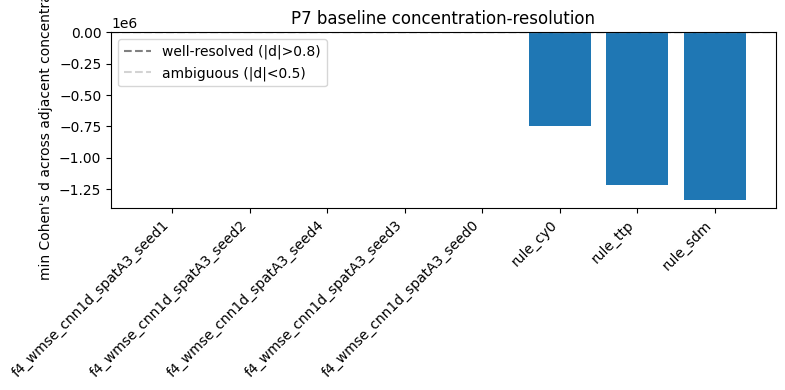

In [2]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(df["method_id"], df["min_cohens_d_adjacent"])
ax.set_ylabel("min Cohen's d across adjacent concentrations")
ax.set_title("P7 baseline concentration-resolution")
# Symmetric reference lines — current baselines have negative d (TTP decreases with log-conc)
ax.axhline(0.8, color="gray", linestyle="--", label="well-resolved (|d|>0.8)")
ax.axhline(-0.8, color="gray", linestyle="--")
ax.axhline(0.5, color="lightgray", linestyle="--", label="ambiguous (|d|<0.5)")
ax.axhline(-0.5, color="lightgray", linestyle="--")
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.savefig(FIGS_DIR / "p7_baseline_min_cohens_d.pdf")
plt.show()

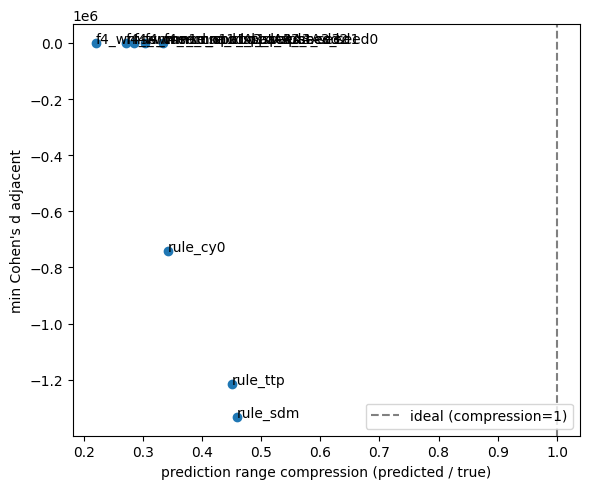

In [3]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(df["prediction_range_compression"], df["min_cohens_d_adjacent"])
for _, row in df.iterrows():
    ax.annotate(row["method_id"], (row["prediction_range_compression"], row["min_cohens_d_adjacent"]))
ax.set_xlabel("prediction range compression (predicted / true)")
ax.set_ylabel("min Cohen's d adjacent")
ax.axvline(1.0, color="gray", linestyle="--", label="ideal (compression=1)")
plt.legend()
plt.tight_layout()
plt.savefig(FIGS_DIR / "p7_compression_vs_resolution.pdf")
plt.show()

## Primary metric: min pairwise concentration AUC

Cohen's d underflows on rule-based methods (they produce one prediction per well, so within-concentration-group variance is 0 → d → ∞ numerically). Mann-Whitney U AUC is bounded in [0, 1] and honest across method families:

- **1.0** = adjacent concentration groups are perfectly separable from predicted TTP alone.
- **0.5** = predictions carry no information about which of two adjacent concentrations a pixel belongs to (chance).

Report leads with this metric; Cohen's d retained as diagnostic/secondary.

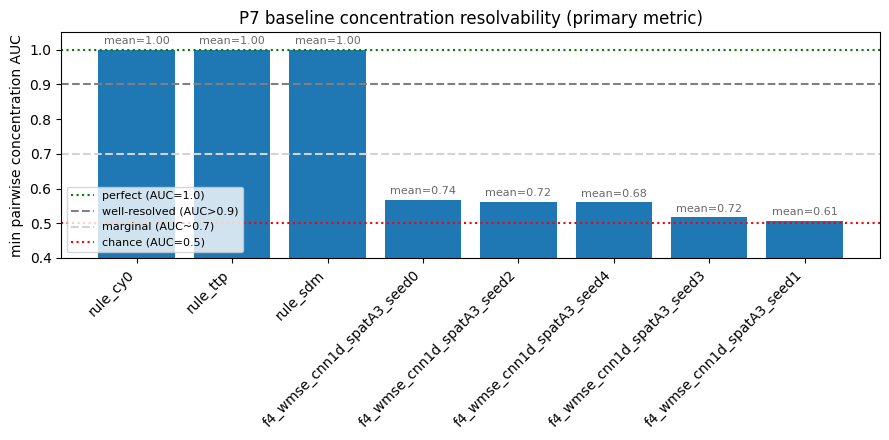

In [4]:
# Sort by AUC descending to make the ranking directly readable.
df_auc = df.sort_values("min_pairwise_auc_offdiag", ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.bar(df_auc["method_id"], df_auc["min_pairwise_auc_offdiag"], color="#1f77b4")
ax.set_ylabel("min pairwise concentration AUC")
ax.set_title("P7 baseline concentration resolvability (primary metric)")
ax.axhline(1.0, color="green",  linestyle=":", label="perfect (AUC=1.0)")
ax.axhline(0.9, color="gray",   linestyle="--", label="well-resolved (AUC>0.9)")
ax.axhline(0.7, color="lightgray", linestyle="--", label="marginal (AUC~0.7)")
ax.axhline(0.5, color="red",    linestyle=":", label="chance (AUC=0.5)")
ax.set_ylim(0.4, 1.05)
# Annotate the mean-AUC on top of each bar for full-picture view.
for bar, mean_auc in zip(bars, df_auc["mean_pairwise_auc_offdiag"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f"mean={mean_auc:.2f}", ha="center", va="bottom", fontsize=8, color="dimgray")
plt.xticks(rotation=45, ha="right")
plt.legend(loc="lower left", fontsize=8)
plt.tight_layout()
plt.savefig(FIGS_DIR / "p7_baseline_pairwise_auc.pdf")
plt.show()